In [132]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch
import torch.nn.functional as F

from scipy.stats import ttest_rel, ttest_1samp

from transformers import GPT2LMHeadModel, GPT2Tokenizer, logging

logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
#

cuda


In [4]:
model_name = "gpt2-large"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model.eval();

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [28]:
num_embed = model.config.n_embd
num_layer = model.config.n_layer
num_head = model.config.n_head
head_dim = num_embed // num_head

num_embed, num_layer, num_head, head_dim

(1280, 36, 20, 64)

# Define hook function

In [61]:
# Global variables
layer2silence = 100
head2silence = 100
token2silence = 4000

# Define hook function
def hook_silence(num_layer):
  def hook(module, input):
    # print(f'Module Name: {module.__class__.__name__}')
    # print(f'Input Type: {type(input)}')
    # print(f'Input length: {len(input)}')
    # print(f'Input Shape: {input[0].shape}')

    n_batches, n_tokens, num_embed = input[0].shape

    h = input[0].view(n_batches, n_tokens, num_head, head_dim)

    if num_layer == layer2silence:

      # Ablate
      h[:,token2silence, head2silence, :] = torch.zeros_like(h[:,token2silence, head2silence, :])

      # Concatenate
      h = h.view(n_batches,n_tokens,num_embed)

      input = (h, *input[1:])

    return input
  return hook

In [62]:
if 'hh' in globals():
  for h in hh:
    h.remove()

hh = []
for layeri in range(num_layer):
  h = model.transformer.h[layeri].attn.c_proj.register_forward_pre_hook(hook_silence(layeri))
  hh.append(h)


# Import text, tokenize and forward-pass through model

In [86]:
text = "Peanut butter and pineapple taste great on pizza"
tokens = tokenizer.encode(text, return_tensors='pt').to(device)

for idx, tok in enumerate(tokens[0]):
  print(f'Token position {idx:2} is index {tok:6} and is "{tokenizer.decode(tok)}" ')

butter_idx = tokens[0].tolist().index(tokenizer.encode(' butter')[0])
pineapple_idx = tokens[0].tolist().index(tokenizer.encode(' pineapple')[0])
pizza_idx = tokens[0].tolist().index(tokenizer.encode(' pizza')[0])

print('\n')
print(f'Butter index: {butter_idx}')
print(f'Pineapple index: {pineapple_idx}')
print(f'Pizza index: {pizza_idx}')

Token position  0 is index   6435 and is "Pe" 
Token position  1 is index  20651 and is "anut" 
Token position  2 is index   9215 and is " butter" 
Token position  3 is index    290 and is " and" 
Token position  4 is index  45540 and is " pineapple" 
Token position  5 is index   6938 and is " taste" 
Token position  6 is index   1049 and is " great" 
Token position  7 is index    319 and is " on" 
Token position  8 is index  14256 and is " pizza" 


Butter index: 2
Pineapple index: 4
Pizza index: 8


In [64]:
# Forward-pass through the model
with torch.no_grad():
  out_clean = model(tokens, output_hidden_states=True)

# Calculate cosine similarities between butter-pizza and pineapple-pizza pairs

In [87]:
cs_clean = np.zeros((num_layer,2)) #0 - cosine-similarity between "butter-pizza" and 1 - between "pineapple-pizza"

for layeri in range(num_layer):

  cs_clean[layeri,0] = F.cosine_similarity(out_clean.hidden_states[layeri+1][:,butter_idx,:], out_clean.hidden_states[layeri+1][:,pizza_idx,:])
  cs_clean[layeri,1] = F.cosine_similarity(out_clean.hidden_states[layeri+1][:,pineapple_idx,:], out_clean.hidden_states[layeri+1][:,pizza_idx,:])


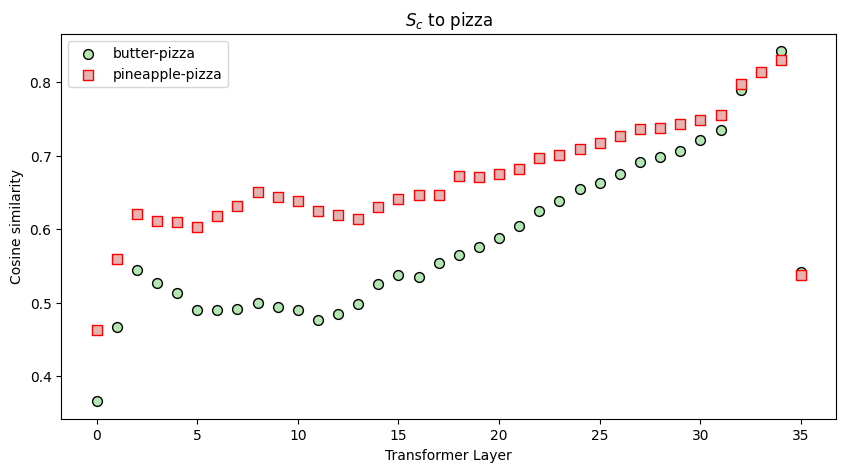

In [88]:
# Visualize
fig = plt.figure(figsize=(10,5))
plt.scatter(range(num_layer), cs_clean[:,0], marker='o', color='k', s=50, facecolor=[.7,.9,.7,1],label="butter-pizza")
plt.scatter(range(num_layer), cs_clean[:,1], marker='s', color='r', s=50, facecolor=[.9,.7,.7,1],label="pineapple-pizza")

plt.legend()
plt.xlabel('Transformer Layer')
plt.ylabel('Cosine similarity')
plt.title(r'$S_c$ to pizza')

plt.show()

# Modify the activation for a specific head and token-index for all layers

In [91]:
# Global variables
head2silence = 5
token2silence = pineapple_idx

cs_silenced = np.zeros((num_layer,2))

for layeri in range(num_layer):
  layer2silence = layeri

  with torch.no_grad():
    out_silenced = model(tokens, output_hidden_states=True)

  cs_silenced[layeri,0]=F.cosine_similarity(out_silenced.hidden_states[layeri+1][:,butter_idx,:], out_silenced.hidden_states[layeri+1][:,pizza_idx,:])
  cs_silenced[layeri,1]=F.cosine_similarity(out_silenced.hidden_states[layeri+1][:,pineapple_idx,:], out_silenced.hidden_states[layeri+1][:,pizza_idx,:])



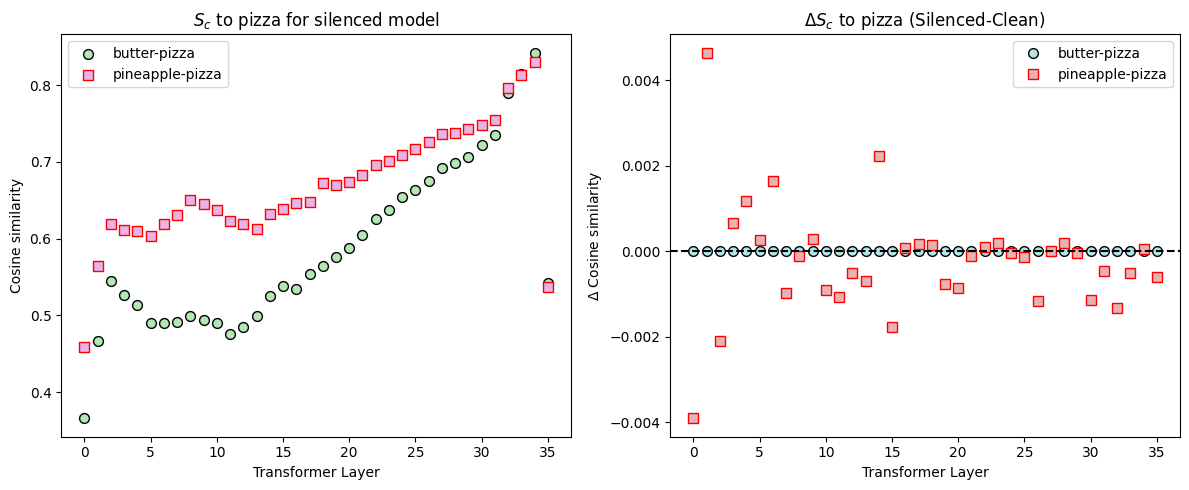

In [118]:
# visualize
fig, axs = plt.subplots(1,2, figsize=(12,5), layout='tight')

axs[0].scatter(range(num_layer), cs_silenced[:,0], s=50, color='k', marker='o', facecolor=[.7,.9,.7,1],label="butter-pizza")
axs[0].scatter(range(num_layer), cs_silenced[:,1], s=50, color='r', marker='s', facecolor=[.9,.7,.9,1],label="pineapple-pizza")

axs[0].set(xlabel='Transformer Layer', ylabel='Cosine similarity', title=r'$S_c$ to pizza for silenced model')
axs[0].legend()

axs[1].plot(cs_silenced[:,0]-cs_clean[:,0], 'ko', ms=7, mfc=[.7,.9,.9,1], label="butter-pizza")
axs[1].plot(cs_silenced[:,1]-cs_clean[:,1], 'rs', ms=7, mfc=[.9,.7,.7,1], label="pineapple-pizza")
axs[1].axhline(y=0, color='k', linestyle='--')

axs[1].set(xlabel='Transformer Layer', ylabel='$\\Delta$ Cosine similarity', title=r'$\Delta S_c$ to pizza (Silenced-Clean)')
axs[1].legend()
plt.show()


# Modify the activation for all heads and token-index for all layers

In [120]:
# Global variables
token2silence = pineapple_idx

cs_silenced_all = np.zeros((num_layer, num_head))

for layeri in range(num_layer):
  layer2silence = layeri
  for headi in range(num_head):
    head2silence = headi

    with torch.no_grad():
      out_silenced = model(tokens, output_hidden_states=True)

    cs_silenced_all[layeri, headi]=F.cosine_similarity(out_silenced.hidden_states[layeri+1][:,pineapple_idx,:], out_silenced.hidden_states[layeri+1][:,pizza_idx,:])



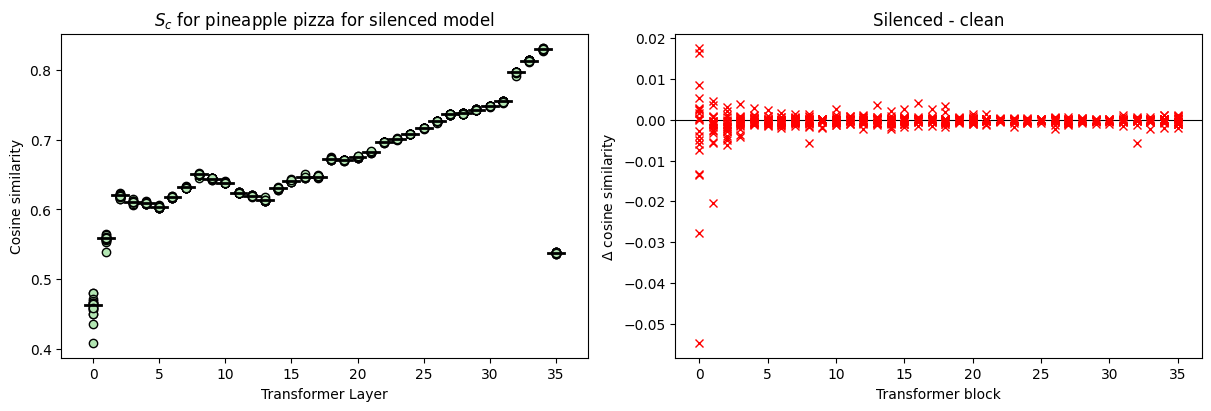

In [134]:
# Visualize
fig, axs = plt.subplots(1,2,figsize=(12,4), layout='constrained')

for i in range(num_layer):
  axs[0].plot(np.zeros(num_head)+i, cs_silenced_all[i,:], 'ko', mfc=[.7,.9,.7,1])
  axs[0].plot([i-.6,i+.6], np.ones(2)*cs_clean[i,1], 'k-', lw=2)

  # Run a t-test
  tres = ttest_1samp(cs_silenced_all[i,:]-cs_clean[i,1],0)
  if tres.pvalue<(.05/num_layer):
      axs[1].plot(np.zeros(num_head)+i,cs_silenced_all[i,:]-cs_clean[i,1],'ko',markerfacecolor=[.9,.7,.7,.5])
  else:
      axs[1].plot(np.zeros(num_head)+i,cs_silenced_all[i,:]-cs_clean[i,1],'rx')

axs[0].set(xlabel='Transformer Layer', ylabel='Cosine similarity', title=r'$S_c$ for pineapple pizza for silenced model')

axs[1].set(xlabel='Transformer block',ylabel='$\\Delta$ cosine similarity',title='Silenced - clean')
axs[1].axhline(0,color='k',linewidth=.8,zorder=-10)

plt.show()